In [ ]:
import os
os.chdir(r'c:\Users\QQ\OneDrive\桌面\课程设计报告_Lendingclub\ipynb文件（代码和输出结果）')

In [3]:
import pandas as pd
df = pd.read_csv("loan_encoded.csv")
df = df.drop(['addr_state_','purpose_'], axis=1)
df.head(10)

,loan_amnt,term,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,dti,...,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,5000.0,36,2,10.0,3,24000.0,2,48,1,27.65,...,861.07,0.00,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045
1,2500.0,60,3,0.5,3,30000.0,1,48,10,1.00,...,435.17,0.00,117.08,1.11,28,0.0,0.0,0.0,0.0,32068.620045
2,2400.0,36,3,10.0,3,12252.0,3,48,1,8.72,...,603.65,0.00,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045
3,10000.0,36,3,10.0,3,49200.0,1,48,1,20.00,...,2209.33,16.97,0.00,0.00,12,0.0,0.0,0.0,0.0,32068.620045
4,3000.0,60,2,1.0,3,80000.0,1,48,2,17.94,...,1009.07,0.00,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045
5,5000.0,36,1,3.0,3,36000.0,1,48,1,11.20,...,631.38,0.00,0.00,0.00,4,0.0,0.0,0.0,0.0,32068.620045
6,7000.0,60,3,8.0,3,47004.0,3,48,2,23.51,...,3025.99,0.00,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045
7,3000.0,36,5,9.0,3,48000.0,1,48,1,5.35,...,938.14,0.00,0.00,0.00,13,0.0,0.0,0.0,0.0,32068.620045
8,5600.0,60,6,4.0,1,40000.0,1,48,10,5.55,...,294.94,0.00,189.06,2.09,41,0.0,0.0,0.0,0.0,32068.620045
9,5375.0,60,2,0.5,3,15000.0,2,48,10,18.08,...,533.42,0.00,269.29,2.52,34,0.0,0.0,0.0,0.0,32068.620045


In [4]:
# 根据特征重要性图筛去几列：
df2 = df.drop(['acc_now_delinq','collections_12_mths_ex_med'], axis=1)


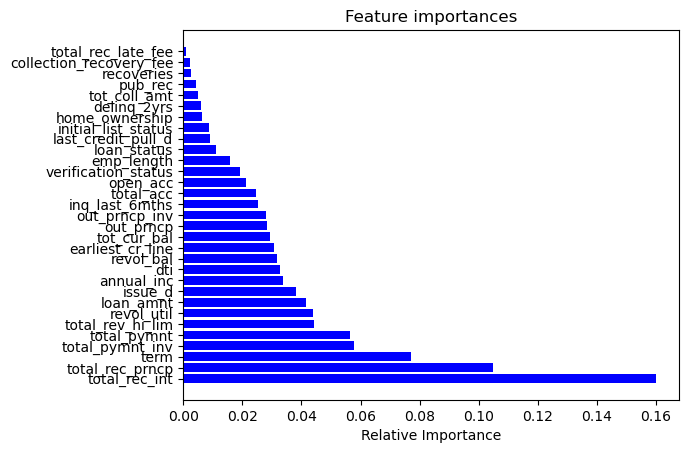

验证集准确率: 0.75
测试集准确率: 0.75


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 目标列名为'grade'
# 首先分割出10%的数据作为测试集
X_train, X_test, y_train, y_test = train_test_split(
    df2.drop('grade', axis=1),
    df2['grade'],
    test_size=0.1,  # 10% 作为测试集
    random_state=123
)

# 然后从剩余的90%中分割出20%作为验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,  # 从剩余的90%中再分割出20%作为验证集
    random_state=123
)

# 创建随机森林分类器实例，并设置指定的参数
rf_classifier2 = RandomForestClassifier(
    n_estimators=132, 
    criterion='entropy', 
    max_depth=39, 
    max_features='sqrt', 
    min_samples_leaf=2, 
    min_samples_split=6, 
    random_state=111,  # 确保结果的可复现性
    class_weight='balanced'
)

# 训练模型
rf_classifier2.fit(X_train, y_train)

# 获取特征重要性并绘图
feature_importances = rf_classifier2.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure()
plt.title("Feature importances")
plt.barh(range(len(indices)), feature_importances[indices], color='b', align='center')
# 使用 X_train 的列名作为 y 轴的标签
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# 使用验证集进行预测
y_val_pred = rf_classifier2.predict(X_val)
# 计算验证集的准确率
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"验证集准确率: {val_accuracy:.2f}")

# 使用测试集对模型进行评价
y_test_pred = rf_classifier2.predict(X_test)
# 计算测试集的准确率
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"测试集准确率: {test_accuracy:.2f}")

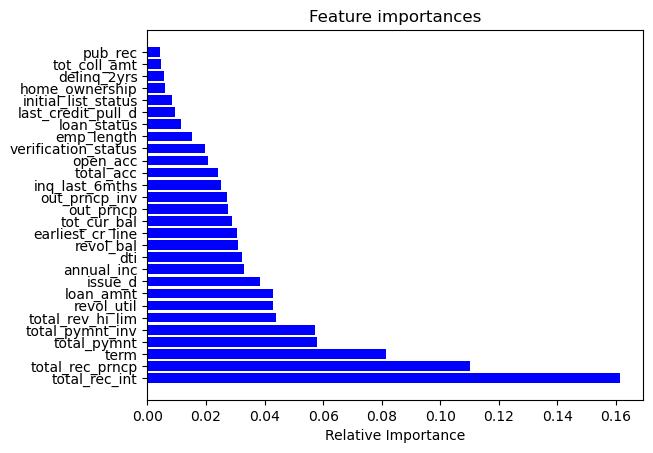

验证集准确率: 0.76
测试集准确率: 0.76


In [9]:
# 根据特征重要性图筛去几列：
df2 = df.drop(['acc_now_delinq','collections_12_mths_ex_med','total_rec_late_fee','recoveries','collection_recovery_fee'], axis=1)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 目标列名为'grade'
# 首先分割出10%的数据作为测试集
X_train, X_test, y_train, y_test = train_test_split(
    df2.drop('grade', axis=1),
    df2['grade'],
    test_size=0.1,  # 10% 作为测试集
    random_state=123
)

# 然后从剩余的90%中分割出20%作为验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,  # 从剩余的90%中再分割出20%作为验证集
    random_state=123
)

# 创建随机森林分类器实例，并设置指定的参数
rf_classifier2 = RandomForestClassifier(
    n_estimators=132, 
    criterion='entropy', 
    max_depth=39, 
    max_features='sqrt', 
    min_samples_leaf=2, 
    min_samples_split=6, 
    random_state=111,  # 确保结果的可复现性
    class_weight='balanced'
)

# 训练模型
rf_classifier2.fit(X_train, y_train)

# 获取特征重要性并绘图
feature_importances = rf_classifier2.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure()
plt.title("Feature importances")
plt.barh(range(len(indices)), feature_importances[indices], color='b', align='center')
# 使用 X_train 的列名作为 y 轴的标签
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# 使用验证集进行预测
y_val_pred = rf_classifier2.predict(X_val)
# 计算验证集的准确率
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"验证集准确率: {val_accuracy:.2f}")

# 使用测试集对模型进行评价
y_test_pred = rf_classifier2.predict(X_test)
# 计算测试集的准确率
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"测试集准确率: {test_accuracy:.2f}")

In [16]:
from sklearn.metrics import f1_score

# 计算 F1 分数，'weighted' 选项处理多分类问题中的类别不平衡
f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"测试集的 F1 分数: {f1:.2f}")

测试集的 F1 分数: 0.76


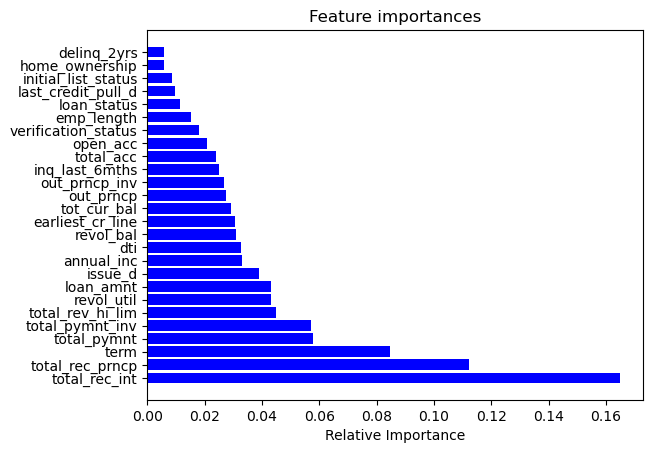

验证集准确率: 0.77
测试集准确率: 0.77


In [18]:
# 根据特征重要性图筛去几列：
df2 = df.drop(['acc_now_delinq','collections_12_mths_ex_med','total_rec_late_fee','recoveries','collection_recovery_fee','pub_rec','tot_coll_amt'], axis=1)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 目标列名为'grade'
# 首先分割出10%的数据作为测试集
X_train, X_test, y_train, y_test = train_test_split(
    df2.drop('grade', axis=1),
    df2['grade'],
    test_size=0.1,  # 10% 作为测试集
    random_state=123
)

# 然后从剩余的90%中分割出20%作为验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,  # 从剩余的90%中再分割出20%作为验证集
    random_state=123
)

# 创建随机森林分类器实例，并设置指定的参数
rf_classifier2 = RandomForestClassifier(
    n_estimators=132, 
    criterion='entropy', 
    max_depth=39, 
    max_features='sqrt', 
    min_samples_leaf=2, 
    min_samples_split=6, 
    random_state=111,  # 确保结果的可复现性
    class_weight='balanced'
)

# 训练模型
rf_classifier2.fit(X_train, y_train)

# 获取特征重要性并绘图
feature_importances = rf_classifier2.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure()
plt.title("Feature importances")
plt.barh(range(len(indices)), feature_importances[indices], color='b', align='center')
# 使用 X_train 的列名作为 y 轴的标签
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# 使用验证集进行预测
y_val_pred = rf_classifier2.predict(X_val)
# 计算验证集的准确率
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"验证集准确率: {val_accuracy:.2f}")

# 使用测试集对模型进行评价
y_test_pred = rf_classifier2.predict(X_test)
# 计算测试集的准确率
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"测试集准确率: {test_accuracy:.2f}")

In [19]:
from sklearn.metrics import f1_score

# 计算 F1 分数，'weighted' 选项处理多分类问题中的类别不平衡
f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"测试集的 F1 分数: {f1:.2f}")

测试集的 F1 分数: 0.77


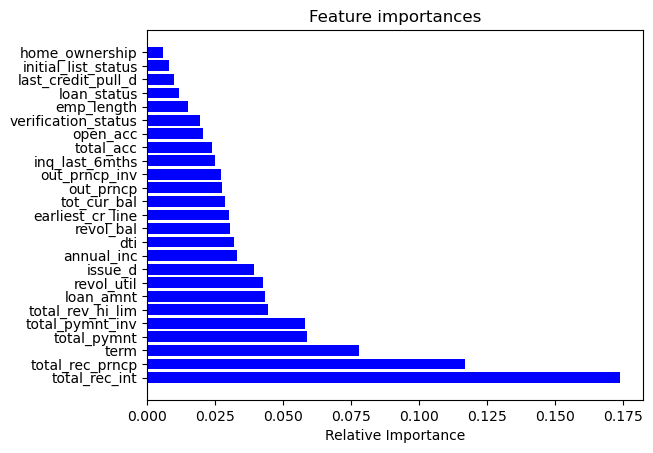

验证集准确率: 0.77
测试集准确率: 0.78


In [21]:
# 根据特征重要性图筛去几列：
df2 = df.drop(['acc_now_delinq','collections_12_mths_ex_med','total_rec_late_fee','recoveries','collection_recovery_fee','pub_rec','tot_coll_amt','delinq_2yrs'], axis=1)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 目标列名为'grade'
# 首先分割出10%的数据作为测试集
X_train, X_test, y_train, y_test = train_test_split(
    df2.drop('grade', axis=1),
    df2['grade'],
    test_size=0.1,  # 10% 作为测试集
    random_state=123
)

# 然后从剩余的90%中分割出20%作为验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,  # 从剩余的90%中再分割出20%作为验证集
    random_state=123
)

# 创建随机森林分类器实例，并设置指定的参数
rf_classifier2 = RandomForestClassifier(
    n_estimators=132, 
    criterion='entropy', 
    max_depth=39, 
    max_features='sqrt', 
    min_samples_leaf=2, 
    min_samples_split=6, 
    random_state=111,  # 确保结果的可复现性
    class_weight='balanced'
)

# 训练模型
rf_classifier2.fit(X_train, y_train)

# 获取特征重要性并绘图
feature_importances = rf_classifier2.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure()
plt.title("Feature importances")
plt.barh(range(len(indices)), feature_importances[indices], color='b', align='center')
# 使用 X_train 的列名作为 y 轴的标签
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# 使用验证集进行预测
y_val_pred = rf_classifier2.predict(X_val)
# 计算验证集的准确率
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"验证集准确率: {val_accuracy:.2f}")

# 使用测试集对模型进行评价
y_test_pred = rf_classifier2.predict(X_test)
# 计算测试集的准确率
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"测试集准确率: {test_accuracy:.2f}")

In [22]:
from sklearn.metrics import f1_score

# 计算 F1 分数，'weighted' 选项处理多分类问题中的类别不平衡
f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"测试集的 F1 分数: {f1:.2f}")

测试集的 F1 分数: 0.77


In [24]:
df.collection_recovery_fee.value_counts()

collection_recovery_fee
0.0000       863797
2.0000           18
1.8000           13
1.5500           12
1.8800           12
              ...  
26.7473           1
7.2263            1
25.2767           1
69.9696           1
1050.1524         1
Name: count, Length: 20704, dtype: int64